In [2]:
%pip install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)

   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Strategic Brief: Onboarding Systems Optimization
**Operational Audit & Resource Allocation Strategy**

### 1. Context & Methodology
This study uses an **Operations Research Simulation** of 1,000 client onboarding cycles to quantify systemic friction. The goal is to identify the "Founder-Led Trap"—a condition where lack of process clarity forces executive intervention, creating a scalability ceiling.

### The Problem:
Early-stage B2B AI implementations often rely on personality-driven execution. This leads to:
* **The Founder Tax:** High-cost executive intervention on low-level tasks.
* **Support Entropy:** Exponential query rates from non-technical clients.
* **Tail Risk:** Unpredictable activation delays (TTFV) impacting revenue recognition.

C:\Users\SHANIA\AppData\Local\Temp\ipykernel_8424\3352016197.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='segment', y='ttfv_days', palette='vlag', ax=ax[1])


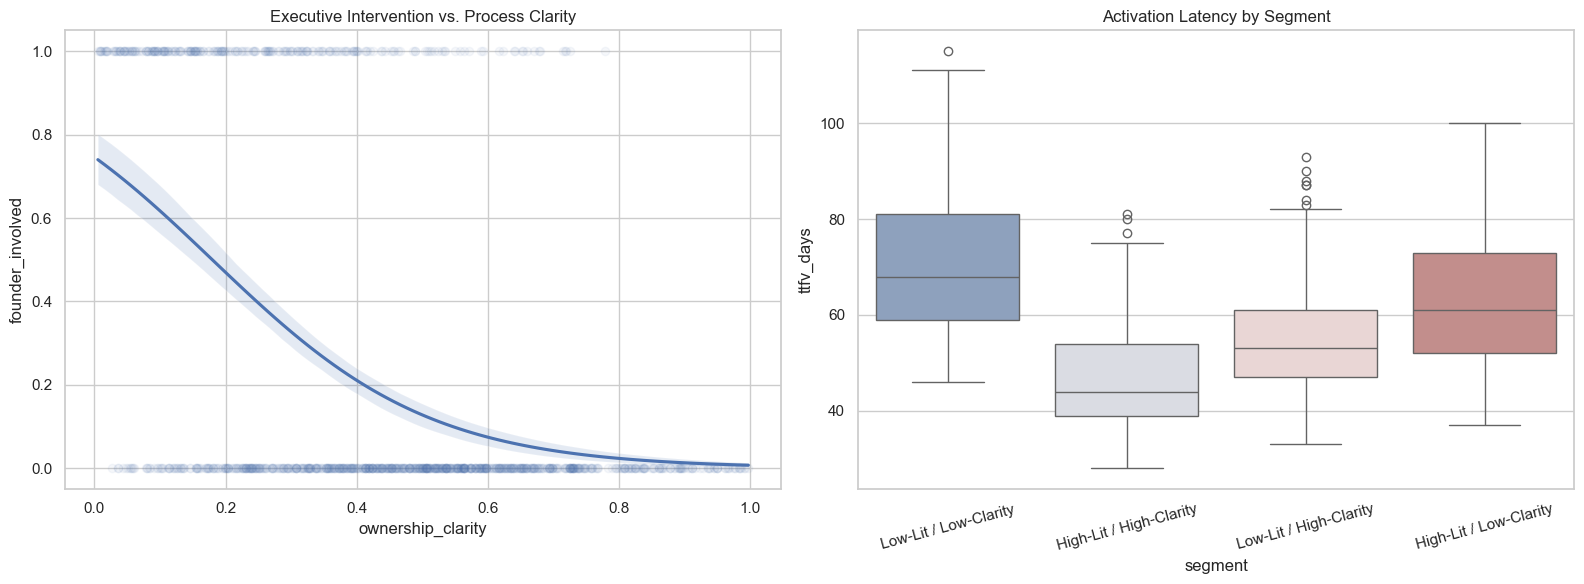

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown

# Load data for visualization context
df = pd.read_csv('../data/onboarding_data_v2.csv')
sns.set_theme(style="whitegrid")

# Define the "Toxic Quadrant" for the report
df['lit_group'] = pd.qcut(df['tech_literacy'], 2, labels=['Low-Lit', 'High-Lit'])
df['clarity_group'] = pd.qcut(df['ownership_clarity'], 2, labels=['Low-Clarity', 'High-Clarity'])
df['segment'] = df['lit_group'].astype(str) + " / " + df['clarity_group'].astype(str)

# High-Level Visuals for the Stakeholder
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Visual A: The Founder Tax Probability
sns.regplot(data=df, x='ownership_clarity', y='founder_involved', 
            logistic=True, scatter_kws={'alpha':0.05}, ax=ax[0])
ax[0].set_title("Executive Intervention vs. Process Clarity")

# Visual B: The Revenue Risk (TTFV by Segment)
sns.boxplot(data=df, x='segment', y='ttfv_days', palette='vlag', ax=ax[1])
ax[1].set_title("Activation Latency by Segment")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()